# Latent interpretability — phase 1 (sections 1–4 + 6)

Companion to `stratified_performance_latent_clusters.ipynb`. Four questions:

1. **§2 — Are the raw-patch clusters consistent with the VAE-latent clusters?**
   If yes, the VAE preserved the discriminative structure of the raw signal.
   If no, the VAE compressed away something the raw patches show — interesting in
   its own right.

2. **§3 — How much agreement?** NMI + ARI + cross-tabulation between v1 (latent)
   and v2 (patch) cluster labels.

3. **§4 — Which of the 16 latent dimensions matter?** Spearman correlation of
   each dim against per-station MAE, per (folder, variable). Identifies the
   dims the downstream model is most sensitive to.

4. **§6 — Does TESSERA exploit within-cluster structure?** For each cluster,
   does per-station TESSERA lift correlate with how far the station's latent is
   from the cluster centroid? If lift is concentrated at centroids → the model
   uses cluster membership as a coarse signal. If at the boundaries → it's
   doing something finer.

**§5 (latent ablation) deferred** — requires re-running inference with one
latent dim zeroed at a time. Returns when we're ready to spend the compute.

**Compute budget for §2:** raw patches are float32 (N, 64, 64, 128) ≈ 2 MB
per station. The notebook loads patches only for evaluated test stations
(~5k stations across the five regions) and spatial-avg-pools to 8×8×128 before
PCA → ~160 MB working set. If you sized up to all 35k TESSERA-valid stations
the working set would be ~1 GB; tractable but slower. Default config below uses
the test-station subset for fidelity-to-v1 comparison.


In [1]:
import sys
import warnings
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.cluster.vq import kmeans2
from scipy.stats import spearmanr
from scipy.special import comb as scipy_comb

sys.path.insert(0, str(Path.cwd()))
import _helpers
import importlib
importlib.reload(_helpers)
from _helpers import (
    RunCategory,
    _top_n_experiments,
    _augment_df_with_classification,
    output_dir_for_folder,
)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.constrained_layout.use': True,
})


In [2]:
# Mirrors stratified_performance_latent_clusters.ipynb's config. Keep the
# same K_HEADLINE so v1 ↔ v2 cluster counts match for the agreement
# analysis.
FOLDERS = [
    'snapshot_14y_eu',
    'snapshot_14y_us',
    'snapshot_14y_east_asia',
    'snapshot_14y_australia',
    'snapshot_14y_southern_africa',
]
SEEDS = [42, 123, 456]
VARIABLES = ['t2m', 'wind']
DIST_PREF = {'t2m': ['gaussian'], 'wind': ['truncated_normal', 'gaussian']}
DATASET_DIR = Path('../.tmp_output/dataset_timestamp_global')

# Shared TESSERA paths.
VAE_LATENTS_PATH = Path('../.tmp_output/processed/station_latents_lat16_grad0.5.npy')
VAE_LATENTS_CSV  = Path('../.tmp_output/processed/tessera_global/station_list_filtered.csv')
TESSERA_PATCHES_PATH = Path('../.tmp_output/processed/tessera_global/patch_embeddings_2024.npy')

K_HEADLINE = 8
KMEANS_SEED = 42

# §2 settings: spatial avg-pool factor for patches before PCA.
# 64×64×128 / 64 = 8×8×128 ≈ 8 192 floats per station. Tractable for ~5 k
# stations (~160 MB working set after PCA).
PATCH_POOL_FACTOR = 8           # 64×64 → 8×8
PATCH_PCA_DIM     = 64          # how many PCs to keep before kmeans

# §4/§6 settings.
N_TOP_EXAMPLES = 5


In [3]:
# Mirror v1's data-loading scaffold so this notebook stands alone.
# Includes the {var}_distribution filter fix from the cluster notebook.
df_all = _helpers.load_all_results(FOLDERS, seeds=SEEDS)
df_all = _augment_df_with_classification(df_all)
print(f'Loaded {len(df_all)} run records.')


def pick_winner_pair(df_sub: pd.DataFrame, variable: str) -> dict | None:
    dist_col = f'{variable}_distribution'
    def in_dist(df, dist):
        if dist_col not in df.columns:
            return df.iloc[0:0]
        return df[df[dist_col] == dist]
    chosen_dist = None; tessera_name = None
    for dist in DIST_PREF[variable]:
        cands = in_dist(df_sub, dist)
        if cands.empty:
            continue
        top = _top_n_experiments(
            cands, variable, dist,
            RunCategory.TESSERA_VANILLA, 'single', top_n=1, encoder='vae',
        )
        if top:
            chosen_dist = dist
            tessera_name = top[0]
            break
    if not tessera_name:
        return None
    baseline_name = None
    baseline_dist = None
    for dist in [chosen_dist] + [d for d in DIST_PREF[variable] if d != chosen_dist]:
        cands = in_dist(df_sub, dist)
        if cands.empty:
            continue
        top = _top_n_experiments(
            cands, variable, dist,
            RunCategory.TRAINED_NO_TESSERA, 'single', top_n=1,
        )
        if top:
            baseline_dist = dist
            baseline_name = top[0]
            break
    if not baseline_name:
        return None
    return {
        'variable': variable, 'folder': None,
        'tessera_distribution': chosen_dist, 'tessera_experiment': tessera_name,
        'baseline_distribution': baseline_dist, 'baseline_experiment': baseline_name,
    }


winners = []
for folder in FOLDERS:
    sub = df_all[df_all['source_folder'] == folder]
    if sub.empty:
        continue
    for variable in VARIABLES:
        pair = pick_winner_pair(sub, variable)
        if pair is None:
            continue
        pair['folder'] = folder
        winners.append(pair)
winners_df = pd.DataFrame(winners)[
    ['folder', 'variable', 'tessera_distribution', 'tessera_experiment',
     'baseline_distribution', 'baseline_experiment']
]
print()
print('=== Winners ===')
with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    print(winners_df.to_string(index=False))


Loaded 2607 run records.

=== Winners ===
                      folder variable tessera_distribution                                                  tessera_experiment baseline_distribution            baseline_experiment
             snapshot_14y_eu      t2m             gaussian     t2m_snap_vae_lat16_proj8_bilinear_concat_with_elev_no_static_wd              gaussian   t2m_snap_setconv_baseline_wd
             snapshot_14y_eu     wind     truncated_normal wind_truncnormal_snap_vae_lat16_proj8_concat_with_elev_no_static_wd              gaussian  wind_snap_setconv_baseline_wd
             snapshot_14y_us      t2m             gaussian          t2m_snap_vae_lat16_proj8_mlp_concat_with_elev_no_static_wd              gaussian  t2m_snap_bilinear_baseline_wd
             snapshot_14y_us     wind             gaussian           wind_snap_vae_lat16_proj8_mlp_film_with_elev_no_static_wd              gaussian wind_snap_bilinear_baseline_wd
      snapshot_14y_east_asia      t2m             gaussian

In [4]:
def load_station_records(folder, experiment, role, variable, seeds=SEEDS):
    out = []
    for seed in seeds:
        npz = output_dir_for_folder(folder) / f'{experiment}_seed{seed}' / 'test_station_errors.npz'
        if not npz.exists():
            continue
        try:
            d = dict(np.load(npz, allow_pickle=True))
        except Exception:
            continue
        mae_k = f'{variable}_station_mae'
        cnt_k = f'{variable}_station_count'
        if mae_k not in d or cnt_k not in d:
            continue
        n = len(d['station_ids'])
        counts = d[cnt_k]
        for i in range(n):
            if counts[i] == 0:
                continue
            out.append({
                'folder': folder, 'variable': variable, 'role': role,
                'experiment': experiment, 'seed': seed,
                'station_id': str(d['station_ids'][i]),
                'lat': float(d['station_lats'][i]),
                'lon': float(d['station_lons'][i]),
                'elev': float(d['station_elevs'][i]),
                'delta_elev': float(d['station_delta_elevs'][i]),
                'mae': float(d[mae_k][i]),
            })
    return out


records = []
for w in winners:
    records.extend(load_station_records(w['folder'], w['tessera_experiment'], 'tessera', w['variable']))
    records.extend(load_station_records(w['folder'], w['baseline_experiment'], 'baseline', w['variable']))
raw = pd.DataFrame.from_records(records)
station_agg = (
    raw.groupby(['folder', 'variable', 'role', 'station_id'], as_index=False)
       .agg(
           lat=('lat', 'first'),
           lon=('lon', 'first'),
           elev=('elev', 'first'),
           delta_elev=('delta_elev', 'first'),
           mae=('mae', 'mean'),
           mae_std=('mae', 'std'),
           n_seeds=('mae', 'count'),
       ))
station_agg['abs_delta_elev'] = station_agg['delta_elev'].abs()
print(f'station_agg: {len(station_agg):,} rows.')


station_agg: 4,906 rows.


In [5]:
# Load 16-d latents and refit v1 k-means with the same seed so cluster IDs
# match the v1 notebook exactly. (kmeans2 with seed=KMEANS_SEED is
# deterministic given the same input.)
latents_all = np.load(str(VAE_LATENTS_PATH), mmap_mode='r')
csv = pd.read_csv(VAE_LATENTS_CSV)
csv['station_id'] = csv['station_id'].astype(str)
valid_mask = ~np.isnan(latents_all).any(axis=1)
valid_latents = np.array(latents_all[valid_mask], dtype=np.float64)
valid_csv = csv.loc[valid_mask, ['station_id']].reset_index(drop=True)
print(f'Global TESSERA-valid stations: {len(valid_csv):,}')

mu_l = valid_latents.mean(axis=0, keepdims=True)
sigma_l = valid_latents.std(axis=0, keepdims=True) + 1e-12
latents_std = (valid_latents - mu_l) / sigma_l

np.random.seed(KMEANS_SEED)
centroids_v1, labels_v1 = kmeans2(
    latents_std, k=K_HEADLINE, seed=KMEANS_SEED, minit='++',
    iter=200, missing='raise',
)
v1_lookup = pd.DataFrame({
    'station_id': valid_csv['station_id'].values,
    'cluster_v1': labels_v1,
})
station_agg = station_agg.merge(v1_lookup, on='station_id', how='left')
station_agg['cluster_v1'] = station_agg['cluster_v1'].astype('Int64')

# Per-station latent index (for §4 + §6 distance computations later).
sid_to_idx = dict(zip(valid_csv['station_id'].values, range(len(valid_csv))))
print(f'v1 cluster sizes: {dict(Counter(labels_v1).most_common())}')


Global TESSERA-valid stations: 35,390
v1 cluster sizes: {np.int32(3): 8778, np.int32(6): 5322, np.int32(5): 5228, np.int32(0): 4739, np.int32(4): 3498, np.int32(7): 2775, np.int32(2): 2618, np.int32(1): 2432}


In [6]:
# ===========================================================================
# §2  Patch-level clustering (v2)
# ===========================================================================
# For each unique evaluated test station, load its raw 64×64×128 patch,
# spatial-avg-pool to 8×8×128 (= 8 192 floats), then PCA + k-means at the
# same K_HEADLINE as v1.
#
# Approach: mmap the patches file once; iterate stations and accumulate
# pooled vectors into an in-memory array (~160 MB for 5k stations after
# pooling). This is the practical compromise — full-resolution clustering
# on 5k stations would be ~10 GB; spatial-pool keeps the comparison fair to
# v1 (which also operates on a global summary of the patch, not pixel-level
# information) while staying feasible on a workstation.
if not TESSERA_PATCHES_PATH.exists():
    raise FileNotFoundError(
        f'Raw TESSERA patches not found at {TESSERA_PATCHES_PATH}. Adjust '
        f'TESSERA_PATCHES_PATH in the config cell.'
    )

# patches.shape = (N_global, 64, 64, 128) per dense_grid_patches.py docs.
patches_mmap = np.load(str(TESSERA_PATCHES_PATH), mmap_mode='r')
if patches_mmap.ndim != 4:
    raise RuntimeError(
        f'Expected 4D patches (N, 64, 64, 128); got shape {patches_mmap.shape}.'
    )
n_global, ph, pw, n_ch = patches_mmap.shape
print(f'Patches mmap: {patches_mmap.shape} ({patches_mmap.dtype})')
print(f'  Per-station size: {ph}×{pw}×{n_ch} = {ph*pw*n_ch} floats '
      f'(~{ph*pw*n_ch * 4 / 1024 / 1024:.1f} MB raw)')

# CSV is row-aligned with the patches file. Same CSV as VAE latents.
patches_csv = pd.read_csv(VAE_LATENTS_CSV)
patches_csv['station_id'] = patches_csv['station_id'].astype(str)
if len(patches_csv) != n_global:
    raise RuntimeError(
        f'Patches CSV/NPY row mismatch: CSV {len(patches_csv)} vs NPY {n_global}.'
    )
patch_index = dict(zip(patches_csv['station_id'].values, range(n_global)))

unique_sids = station_agg['station_id'].drop_duplicates().tolist()
print(f'Loading patches for {len(unique_sids)} unique evaluated stations...')

pool_h = ph // PATCH_POOL_FACTOR
pool_w = pw // PATCH_POOL_FACTOR
flat_dim = pool_h * pool_w * n_ch
pooled_flat = np.zeros((len(unique_sids), flat_dim), dtype=np.float32)
loaded_sids = []
missing = 0
for i, sid in enumerate(unique_sids):
    idx = patch_index.get(sid)
    if idx is None:
        missing += 1
        loaded_sids.append(None)
        continue
    p = np.array(patches_mmap[idx], dtype=np.float32)              # (64, 64, 128)
    # Average pool: reshape (pool_h, factor, pool_w, factor, ch) → mean over axes 1, 3.
    pooled = p.reshape(pool_h, PATCH_POOL_FACTOR, pool_w, PATCH_POOL_FACTOR, n_ch).mean(axis=(1, 3))
    pooled_flat[i] = pooled.reshape(-1)
    loaded_sids.append(sid)

print(f'  Loaded {len(unique_sids) - missing} of {len(unique_sids)} stations '
      f'({missing} missing from patches CSV).')
print(f'  Pooled representation: {pooled_flat.shape} '
      f'(~{pooled_flat.nbytes / 1024 / 1024:.1f} MB)')

# Filter out missing rows for the PCA + kmeans step.
keep_mask = np.array([sid is not None for sid in loaded_sids])
pooled_kept = pooled_flat[keep_mask]
sids_kept = [sid for sid in loaded_sids if sid is not None]

# PCA via SVD on the centred matrix.
patch_mu = pooled_kept.mean(axis=0, keepdims=True)
centred = pooled_kept - patch_mu
U, S, Vt = np.linalg.svd(centred, full_matrices=False)
patch_pca = centred @ Vt[:PATCH_PCA_DIM].T
explained_var = (S ** 2 / (S ** 2).sum())[:PATCH_PCA_DIM]
print(f'  PCA: top {PATCH_PCA_DIM} PCs explain '
      f'{explained_var.sum() * 100:.1f}% of variance '
      f'(PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%).')

# Standardise the PCA scores before kmeans (same as v1's treatment of latents).
pca_mu = patch_pca.mean(axis=0, keepdims=True)
pca_sigma = patch_pca.std(axis=0, keepdims=True) + 1e-12
patch_pca_std = (patch_pca - pca_mu) / pca_sigma

np.random.seed(KMEANS_SEED)
centroids_v2, labels_v2 = kmeans2(
    patch_pca_std, k=K_HEADLINE, seed=KMEANS_SEED, minit='++',
    iter=200, missing='raise',
)
print(f'\nv2 (patch) cluster sizes: {dict(Counter(labels_v2).most_common())}')

# Merge v2 labels back into station_agg.
v2_lookup = pd.DataFrame({'station_id': sids_kept, 'cluster_v2': labels_v2})
station_agg = station_agg.merge(v2_lookup, on='station_id', how='left')
station_agg['cluster_v2'] = station_agg['cluster_v2'].astype('Int64')

paired = station_agg[
    station_agg['cluster_v1'].notna() & station_agg['cluster_v2'].notna()
]
print(f'Stations with BOTH v1 and v2 labels: {len(paired):,} of {len(station_agg):,}')


Patches mmap: (38870, 64, 64, 128) (float32)
  Per-station size: 64×64×128 = 524288 floats (~2.0 MB raw)
Loading patches for 1728 unique evaluated stations...
  Loaded 1728 of 1728 stations (0 missing from patches CSV).
  Pooled representation: (1728, 8192) (~54.0 MB)
  PCA: top 64 PCs explain 67.8% of variance (PC1=8.1%, PC2=6.5%).

v2 (patch) cluster sizes: {np.int32(5): 601, np.int32(3): 468, np.int32(6): 187, np.int32(2): 143, np.int32(1): 122, np.int32(0): 90, np.int32(7): 77, np.int32(4): 40}
Stations with BOTH v1 and v2 labels: 4,906 of 4,906


Computing v1↔v2 agreement on 1720 stations.

NMI (normalised mutual information): 0.3363
ARI (adjusted Rand index):           0.2326

Rule of thumb:
  NMI ≥ 0.5  → strong cluster-label agreement
  NMI 0.2–0.5 → moderate; both clusterings capture some shared structure
  NMI < 0.2  → weak; the two representations partition stations very differently

Cross-tabulation (rows = v1 latent cluster, cols = v2 patch cluster):
cluster_v2   0   1    2    3   4    5    6   7
cluster_v1                                    
0            0   0    0    1  32   12    0  20
1            1   0    1   48   0   26   35   1
2            0  95    3    8   0   42    1  24
3            0   1  106  101   0  353   43  31
4           55   0    0    5   0   12  105   0
5           26  24   30  291   0   85    1   1
6            5   1    2   12   8   63    0   0
7            0   1    1    1   0    4    2   0


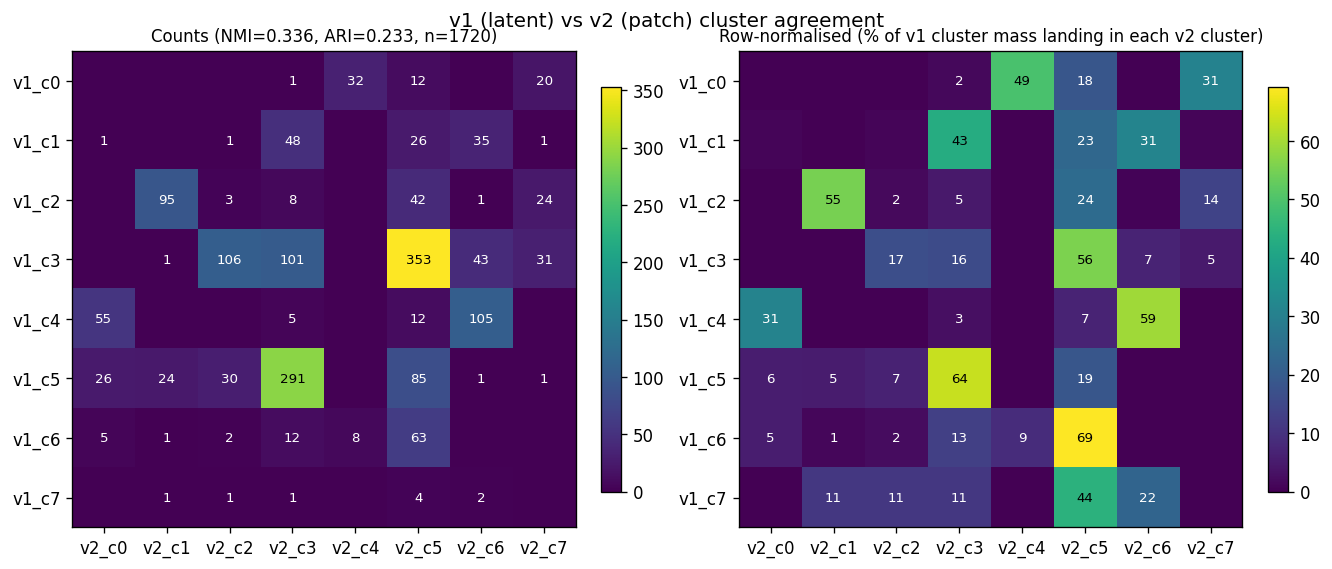

In [7]:
# ===========================================================================
# §3  Agreement analysis — v1 (latent) vs v2 (patch) clusters
# ===========================================================================
# Cross-tabulation + NMI + ARI. Computed on the de-duplicated (one-row-per-
# station) view since each station has one cluster_v1 / cluster_v2.

dedup = (
    station_agg[station_agg['role'] == 'tessera']
    .drop_duplicates('station_id')
    .dropna(subset=['cluster_v1', 'cluster_v2'])
)
a = dedup['cluster_v1'].astype(int).values
b = dedup['cluster_v2'].astype(int).values
n = len(a)
print(f'Computing v1↔v2 agreement on {n} stations.')


def nmi(labels_a: np.ndarray, labels_b: np.ndarray) -> float:
    """Normalised mutual information (arithmetic-mean denominator, the
    default sklearn definition). Returns 0 in degenerate cases."""
    n_total = len(labels_a)
    if n_total == 0:
        return 0.0
    joint = Counter(zip(labels_a.tolist(), labels_b.tolist()))
    marg_a = Counter(labels_a.tolist())
    marg_b = Counter(labels_b.tolist())
    def H(counts):
        return -sum((c / n_total) * math.log(c / n_total) for c in counts.values() if c > 0)
    H_a = H(marg_a); H_b = H(marg_b)
    mi = 0.0
    for (x, y), c in joint.items():
        p_xy = c / n_total
        p_x = marg_a[x] / n_total
        p_y = marg_b[y] / n_total
        if p_xy > 0:
            mi += p_xy * math.log(p_xy / (p_x * p_y))
    if H_a + H_b == 0:
        return 0.0
    return 2.0 * mi / (H_a + H_b)


def ari(labels_a: np.ndarray, labels_b: np.ndarray) -> float:
    """Adjusted Rand Index. Computed from the contingency table without
    any external sklearn dependency."""
    n_total = len(labels_a)
    if n_total == 0:
        return 0.0
    joint = Counter(zip(labels_a.tolist(), labels_b.tolist()))
    marg_a = Counter(labels_a.tolist())
    marg_b = Counter(labels_b.tolist())
    sum_nij_2 = sum(scipy_comb(c, 2) for c in joint.values())
    sum_ai_2  = sum(scipy_comb(c, 2) for c in marg_a.values())
    sum_bj_2  = sum(scipy_comb(c, 2) for c in marg_b.values())
    total_2   = scipy_comb(n_total, 2)
    if total_2 == 0:
        return 0.0
    expected = sum_ai_2 * sum_bj_2 / total_2
    max_idx  = 0.5 * (sum_ai_2 + sum_bj_2)
    denom    = max_idx - expected
    if denom == 0:
        return 0.0
    return (sum_nij_2 - expected) / denom


nmi_val = nmi(a, b)
ari_val = ari(a, b)
print(f'\nNMI (normalised mutual information): {nmi_val:.4f}')
print(f'ARI (adjusted Rand index):           {ari_val:.4f}')
print()
print('Rule of thumb:')
print('  NMI ≥ 0.5  → strong cluster-label agreement')
print('  NMI 0.2–0.5 → moderate; both clusterings capture some shared structure')
print('  NMI < 0.2  → weak; the two representations partition stations very differently')

xtab = pd.crosstab(dedup['cluster_v1'].astype(int),
                   dedup['cluster_v2'].astype(int))
print()
print('Cross-tabulation (rows = v1 latent cluster, cols = v2 patch cluster):')
print(xtab.to_string())

# Heatmap of the contingency table, normalised by ROW (so each v1 cluster
# sums to 100% — answers "given v1 cluster X, where does v2 send those
# stations?").
xtab_norm = xtab.div(xtab.sum(axis=1), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title in [
    (axes[0], xtab.values,
     f'Counts (NMI={nmi_val:.3f}, ARI={ari_val:.3f}, n={n})'),
    (axes[1], xtab_norm.values * 100,
     'Row-normalised (% of v1 cluster mass landing in each v2 cluster)'),
]:
    im = ax.imshow(mat, cmap='viridis', aspect='auto')
    ax.set_xticks(range(K_HEADLINE)); ax.set_yticks(range(K_HEADLINE))
    ax.set_xticklabels([f'v2_c{i}' for i in range(K_HEADLINE)])
    ax.set_yticklabels([f'v1_c{i}' for i in range(K_HEADLINE)])
    ax.set_title(title, fontsize=10)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            colour = 'white' if mat[i, j] < mat.max() * 0.5 else 'black'
            ax.text(j, i, f'{mat[i, j]:.0f}' if mat[i, j] >= 1 else '',
                    ha='center', va='center', fontsize=8, color=colour)
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle('v1 (latent) vs v2 (patch) cluster agreement', fontsize=12, y=1.02)
plt.show()


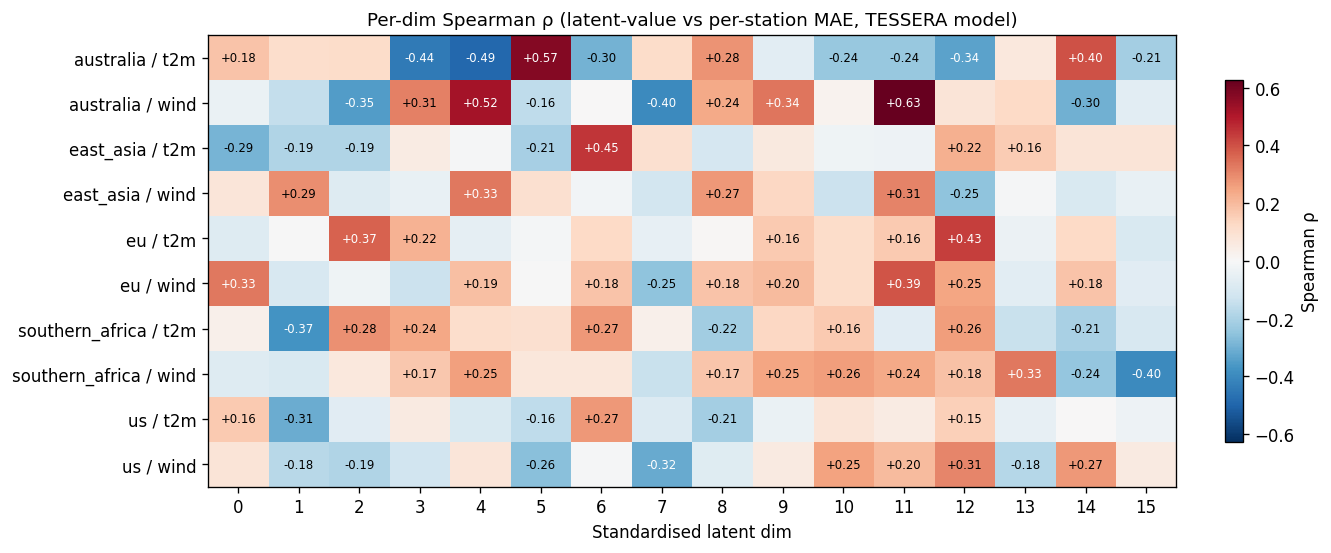


Top-3 most-correlated latent dims per (region, variable):
         region variable  dim  spearman_rho  p_value   n
      australia      t2m    5        0.5736   0.0320  14
      australia      t2m    4       -0.4901   0.0752  14
      australia      t2m    3       -0.4418   0.1138  14
      australia     wind   11        0.6264   0.0220  13
      australia     wind    4        0.5220   0.0673  13
      australia     wind    7       -0.4011   0.1744  13
      east_asia      t2m    6        0.4461   0.0000  88
      east_asia      t2m    0       -0.2893   0.0063  88
      east_asia      t2m   12        0.2212   0.0384  88
      east_asia     wind    4        0.3312   0.0016  88
      east_asia     wind   11        0.3111   0.0032  88
      east_asia     wind    1        0.2906   0.0060  88
             eu      t2m   12        0.4309   0.0000 898
             eu      t2m    2        0.3713   0.0000 898
             eu      t2m    3        0.2200   0.0000 898
             eu     wind   11

In [8]:
# ===========================================================================
# §4  Per-dimension latent importance
# ===========================================================================
# For each (folder, variable) and each of the 16 standardised latent dims,
# Spearman correlation between that dim's value and per-station MAE on the
# TESSERA model. Positive ρ → "stations with higher dim_k value have HIGHER
# MAE" (this dim flags hard cases). Negative ρ → "higher dim_k value =
# LOWER MAE" (dim flags easy cases). Magnitude tells us how task-relevant
# the dim is.
#
# Note: this is correlative; it doesn't tell us the model USES the dim —
# ablation (§5, deferred) would. But strong correlations are necessary for
# the dim to be informative; weak correlations bound the dim's importance
# from above.
tessera_only = (
    station_agg[station_agg['role'] == 'tessera']
    .copy()
)

# Build a station_id → standardised-latent-row lookup, then join.
latent_dim_df = pd.DataFrame(
    latents_std,
    columns=[f'lat_dim_{i}' for i in range(latents_std.shape[1])],
)
latent_dim_df['station_id'] = valid_csv['station_id'].values
tessera_only = tessera_only.merge(latent_dim_df, on='station_id', how='left')

per_dim_rows = []
for (folder, variable), g in tessera_only.groupby(['folder', 'variable']):
    g = g.dropna(subset=['lat_dim_0'])
    if len(g) < 10:
        continue
    region = folder.replace('snapshot_14y_', '')
    for dim in range(latents_std.shape[1]):
        rho, p = spearmanr(g[f'lat_dim_{dim}'], g['mae'])
        per_dim_rows.append({
            'folder': folder, 'region': region, 'variable': variable,
            'dim': dim, 'spearman_rho': rho, 'p_value': p, 'n': len(g),
        })
dim_corr = pd.DataFrame(per_dim_rows)

# Heatmap: rows = (region, variable), cols = dim, colour = ρ.
pivot_rho = (
    dim_corr
    .assign(row_key=lambda d: d['region'] + ' / ' + d['variable'])
    .pivot(index='row_key', columns='dim', values='spearman_rho')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, max(2.5, 0.45 * len(pivot_rho))))
vmax = pivot_rho.abs().max().max()
im = ax.imshow(pivot_rho.values, cmap='RdBu_r', aspect='auto',
               vmin=-vmax, vmax=vmax)
ax.set_xticks(range(pivot_rho.shape[1])); ax.set_xticklabels(pivot_rho.columns)
ax.set_yticks(range(pivot_rho.shape[0])); ax.set_yticklabels(pivot_rho.index)
ax.set_xlabel('Standardised latent dim')
ax.set_title('Per-dim Spearman ρ (latent-value vs per-station MAE, TESSERA model)')
for i in range(pivot_rho.shape[0]):
    for j in range(pivot_rho.shape[1]):
        v = pivot_rho.values[i, j]
        if abs(v) >= 0.15:
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(v) > vmax * 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
plt.show()

# Headline summary: per (region, variable), the top-3 dims by |ρ|.
print('\nTop-3 most-correlated latent dims per (region, variable):')
top3 = (
    dim_corr.assign(abs_rho=dim_corr['spearman_rho'].abs())
            .sort_values(['region', 'variable', 'abs_rho'], ascending=[True, True, False])
            .groupby(['region', 'variable'])
            .head(3)
)
with pd.option_context('display.float_format', '{:.4f}'.format,
                       'display.width', 200):
    print(top3[['region', 'variable', 'dim', 'spearman_rho', 'p_value', 'n']].to_string(index=False))


Per-cluster: gap vs distance-to-centroid (Spearman correlation):

variable  cluster   n  gap_mean  spearman_rho  p_value
     t2m        0  63    0.1597       -0.0784   0.5414
     t2m        1 109    0.1262        0.1192   0.2172
     t2m        2  86    0.2468       -0.0472   0.6659
     t2m        3 634    0.0531        0.0202   0.6110
     t2m        4 157    0.0556       -0.0807   0.3151
     t2m        5 255    0.1153       -0.0207   0.7423
     t2m        6  91    0.1329        0.0551   0.6040
    wind        0  55    0.0532       -0.1162   0.3981
    wind        1  78    0.1069       -0.0973   0.3966
    wind        2  15    0.0156        0.1821   0.5159
    wind        3 356    0.0742       -0.0604   0.2558
    wind        4 108    0.2009        0.0999   0.3038
    wind        5  45    0.0626       -0.4693   0.0011
    wind        6  90    0.1702       -0.0128   0.9044


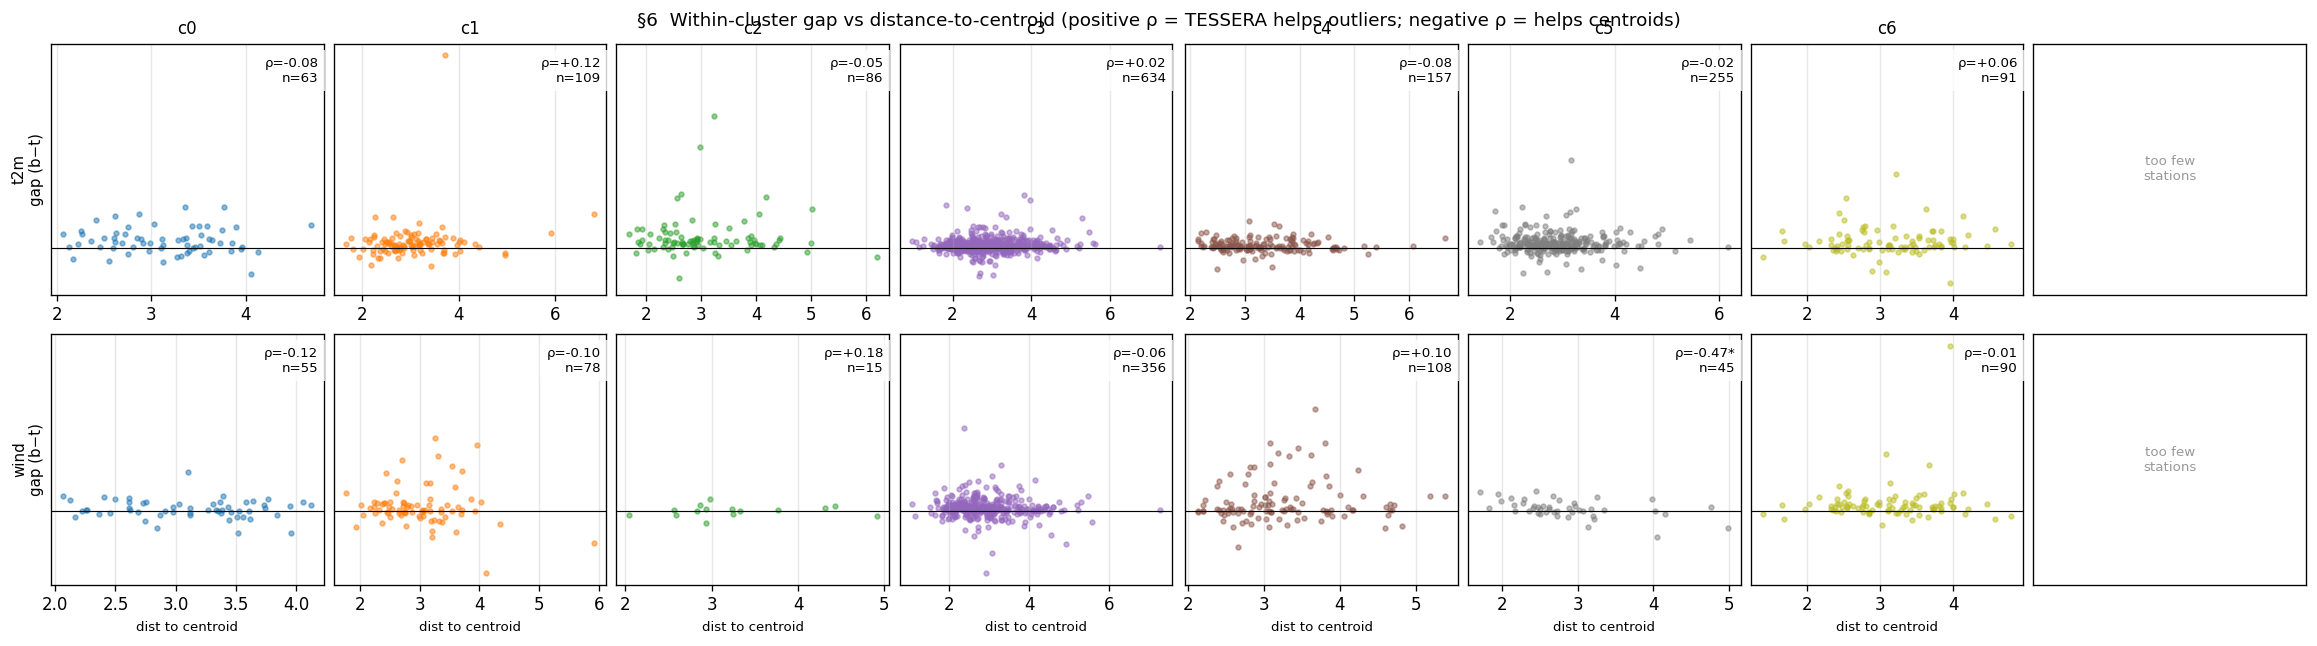

In [9]:
# ===========================================================================
# §6  Per-cluster gap vs distance-to-centroid
# ===========================================================================
# Within each v1 latent cluster, does TESSERA's lift (baseline_MAE −
# tessera_MAE) correlate with how far the station is from the cluster's
# latent centroid? Interpretations:
#   * Negative correlation: stations FAR from centre have LESS lift —
#     TESSERA's advantage is concentrated at the cluster prototype, and
#     fades at the boundaries. The cluster IS the regime; the model uses
#     cluster membership as its main signal.
#   * Positive correlation: stations far from centre (cluster outliers)
#     have MORE lift. TESSERA is exploiting finer latent structure than
#     just the cluster label.
#   * Flat: cluster is just a coarse stratification; lift doesn't track
#     within-cluster latent geometry.

# Step 1: per-station gap (baseline_mae − tessera_mae), per (folder, variable).
gap_wide = (
    station_agg
    .pivot_table(
        index=['folder', 'variable', 'station_id'],
        columns='role', values='mae',
    )
    .reset_index()
)
gap_wide['gap'] = gap_wide['baseline'] - gap_wide['tessera']

# Step 2: latent index + cluster id (TESSERA-side, drop dupes since both
# roles share station_id ↔ cluster_v1).
cluster_map = (
    station_agg[['station_id', 'cluster_v1']]
    .dropna(subset=['cluster_v1'])
    .drop_duplicates('station_id')
)
gap_wide = gap_wide.merge(cluster_map, on='station_id', how='inner')
gap_wide['cluster_v1'] = gap_wide['cluster_v1'].astype(int)

# Step 3: distance of each station's latent from its cluster centroid (in
# standardised latent space).
dist_to_centroid = []
for sid, c in zip(gap_wide['station_id'].values, gap_wide['cluster_v1'].values):
    idx = sid_to_idx.get(sid)
    if idx is None:
        dist_to_centroid.append(np.nan)
        continue
    dist_to_centroid.append(float(np.linalg.norm(latents_std[idx] - centroids_v1[c])))
gap_wide['dist_to_centroid'] = dist_to_centroid

# Step 4: Spearman per (variable, cluster).
summary_rows = []
for (variable, cluster), g in gap_wide.dropna(subset=['gap', 'dist_to_centroid']).groupby(
    ['variable', 'cluster_v1']
):
    if len(g) < 10:
        continue
    rho, p = spearmanr(g['dist_to_centroid'], g['gap'])
    summary_rows.append({
        'variable':  variable,
        'cluster':   int(cluster),
        'n':         len(g),
        'gap_mean':  g['gap'].mean(),
        'spearman_rho': rho,
        'p_value':   p,
    })
gap_dist_summary = pd.DataFrame(summary_rows).sort_values(['variable', 'cluster'])
print('Per-cluster: gap vs distance-to-centroid (Spearman correlation):')
print()
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 200):
    print(gap_dist_summary.to_string(index=False))

# Step 5: scatter per (variable, cluster) — visualises the relationship.
# One row per variable; one column per cluster.
clusters_present = sorted(gap_wide['cluster_v1'].unique())
nrows = len(VARIABLES)
ncols = len(clusters_present)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(2.4 * ncols, 2.6 * nrows),
    squeeze=False, sharey='row',
)
fig.suptitle('§6  Within-cluster gap vs distance-to-centroid '
             '(positive ρ = TESSERA helps outliers; negative ρ = helps centroids)',
             fontsize=11, y=1.005)
cmap = plt.get_cmap('tab10', K_HEADLINE)
for ri, variable in enumerate(VARIABLES):
    for ci, cluster in enumerate(clusters_present):
        ax = axes[ri, ci]
        g = gap_wide[
            (gap_wide['variable'] == variable)
            & (gap_wide['cluster_v1'] == cluster)
        ].dropna(subset=['gap', 'dist_to_centroid'])
        if len(g) < 10:
            ax.text(0.5, 0.5, 'too few\nstations',
                    ha='center', va='center', transform=ax.transAxes,
                    color='#999999', fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        ax.scatter(g['dist_to_centroid'], g['gap'],
                   s=8, alpha=0.5, color=cmap(int(cluster)))
        ax.axhline(0, color='black', linewidth=0.7)
        # Annotate ρ in corner.
        rho, p = spearmanr(g['dist_to_centroid'], g['gap'])
        sig = '*' if p < 0.05 else ''
        ax.text(0.98, 0.95, f'ρ={rho:+.2f}{sig}\nn={len(g)}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
        if ri == 0:
            ax.set_title(f'c{cluster}', fontsize=10)
        if ci == 0:
            ax.set_ylabel(f'{variable}\ngap (b−t)', fontsize=9)
        if ri == nrows - 1:
            ax.set_xlabel('dist to centroid', fontsize=8)
        ax.grid(True, alpha=0.3)
plt.show()


## Reading the four sections

### §2 + §3 — Patch vs latent agreement

A high NMI / ARI score (≥0.5 / ≥0.4) would say "the VAE preserved most of
what the raw patches told us about station similarity." A low score would
say "the VAE compressed away discriminative information" — interesting,
and the cross-tab heatmap shows you *which* clusters got split or merged
between the two representations.

A moderate score (0.2–0.5, the most likely outcome) means the two
representations capture overlapping but non-identical structure. The
cross-tab heatmap then tells you specifically: which v1 clusters are
"clean" (mostly map to one v2 cluster) and which are heterogeneous in
patch space.

### §4 — Per-dim importance

The heatmap shows Spearman ρ per (region, variable, latent dim). What to
look for:

* **Variables with consistent dim signatures across regions.** If `t2m`
  has |ρ|>0.2 on, say, dim 5 in EU AND US AND east_asia, then dim 5 is a
  universally task-relevant feature for t2m (it captures something like
  "general climate proxy that helps temperature prediction").
* **Variable-specific dim signatures.** Dims that are important for `t2m`
  but irrelevant for `wind` (or vice versa) are evidence that TESSERA
  encodes multiple disentangled axes — albedo, roughness, vegetation
  density, etc. — and different downstream variables exploit different
  ones.
* **Region-specific dim signatures.** A dim that helps in `eu` but is flat
  in `australia` suggests that dim encodes something specific to European
  landscapes (e.g., snow albedo, deciduous-forest seasonality).

### §6 — Gap vs distance-to-centroid

This is the most informative diagnostic for *how* the model uses TESSERA:

* **Negative ρ** (lift is biggest at cluster centroids) → the model is
  treating each cluster as a "regime" and benefits most when stations
  unambiguously belong to one regime.
* **Positive ρ** (lift is biggest at cluster boundaries / outliers) → the
  model is exploiting fine within-cluster structure. The cluster label is
  a coarse summary; finer latent geometry matters.
* **Zero / mixed ρ** → cluster identity is the main signal; within-cluster
  latent variation isn't being exploited.

The headline cluster from v1 (largest cross-region gap) is especially
informative to look at here. If c2 (US continental mid-elev, largest t2m
gap) shows strong negative ρ → "TESSERA helps the prototypical US-Rockies
stations most"; strong positive ρ → "TESSERA helps the atypical-for-US
stations most" (e.g., transition zones).

### Caveats

* §4 is correlative. A dim with low |ρ| might still be used by the model
  (the model could use non-monotonic dependence); a dim with high |ρ|
  might be redundant with other dims. The proper test is §5 (deferred
  ablation).
* §6's distance metric is Euclidean in standardised latent space. If the
  model uses a non-Euclidean similarity (e.g., learns its own metric via
  the projection layer), this analysis under-attributes lift to within-
  cluster geometry. Re-running with the 8-d *projected* latents instead
  of the 16-d frozen bottleneck would be a sensible follow-up.
